# Proyecto NovaRetail+: Explorando factores de comportamiento


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('Datos crudos/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `id_cliente` aparece como object y contiene valores alfanuméricos. Los IDs funcionan como identificadores únicos y no requieren operaciones matemáticas por ello no requieren transformación adicional. 


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

**Corregir el tipo de dato**

No se requieren correcciones de tipo de dato. La columna `edad` aparece como float64, aunque sus valores son enteros. Esto no afecta el análisis, pero podría convertirse a int64 solo por presentación.

In [4]:
# verificar cambios
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  str    
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  str    
 10  region                     15000 non-null  str    
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), str(3)
memory usage: 1.4 MB


#### Explorar variables numéricas

In [5]:
# Estadísticas descriptivas de variables numéricas
variables_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[variables_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


Diagnóstico inicial de variables numéricas
- `edad` — Distribución bastante simétrica, mediana está muy cerca de la media
- `nivel_ingreso` — Rango amplio de diversidad de ingresos
- `visitas_mes` — Distribución bastante simétrica, mediana está muy cerca de la media
- `compras_mes` — 25% de clientes no compran nada (Q1 = 0)
- `gasto_publicidad_dirigida` — 25% de clientes no tienen gasto de publicidad dirigida (Q1 = 0)
- `satisfaccion` —  La satisfacción promedio cerca del punto medio de la escala indica que los clientes están moderadamente satisfechos
- `ingreso_anual` — 25% de clientes no genera ingresos para NovaRetail+


#### Explorar variables binarias

In [6]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("miembro_premium:")
print(df['miembro_premium'].value_counts())
print(df['miembro_premium'].value_counts(normalize=True) * 100)

print("\nabandono:")
print(df['abandono'].value_counts())
print(df['abandono'].value_counts(normalize=True) * 100)

miembro_premium:
miembro_premium
0    12911
1     2089
Name: count, dtype: int64
miembro_premium
0    86.073333
1    13.926667
Name: proportion, dtype: float64

abandono:
abandono
0    12739
1     2261
Name: count, dtype: int64
abandono
0    84.926667
1    15.073333
Name: proportion, dtype: float64


Diagnóstico inicial de variables binarias

- `miembro_premium` — Sólo el 13.92% de los clientes son premium
- `abandono` — El 15.07% de los clientes abandonaron la plataforma

#### Explorar variables categóricas

In [7]:
# Verificar el número de valores únicos por variable categórica
print("tipo_dispositivo:")
print(df['tipo_dispositivo'].nunique())  
print(df['tipo_dispositivo'].unique())

print("\nregion:")
print(df['region'].nunique())
print(df['region'].unique())

tipo_dispositivo:
3
<StringArray>
['móvil', 'tablet', 'escritorio']
Length: 3, dtype: str

region:
4
<StringArray>
['norte', 'sur', 'este', 'oeste']
Length: 4, dtype: str


In [8]:
# Explorar variables categóricas y cómo se distribuyen
print("tipo_dispositivo:")
print("Frecuencias absolutas:")
print(df['tipo_dispositivo'].value_counts())
print("\nFrecuencias relativas (%):")
print(df['tipo_dispositivo'].value_counts(normalize=True) * 100)

print("\n")

print("region:")
print("Frecuencias absolutas:")
print(df['region'].value_counts())
print("\nFrecuencias relativas (%):")
print(df['region'].value_counts(normalize=True) * 100)

tipo_dispositivo:
Frecuencias absolutas:
tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64

Frecuencias relativas (%):
tipo_dispositivo
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: proportion, dtype: float64


region:
Frecuencias absolutas:
region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64

Frecuencias relativas (%):
region
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: proportion, dtype: float64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — La categoría móvil domina con un 65.45% de uso de los clientes
- `region` — La distribución es equilibrada pero con ligeras diferencias 

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

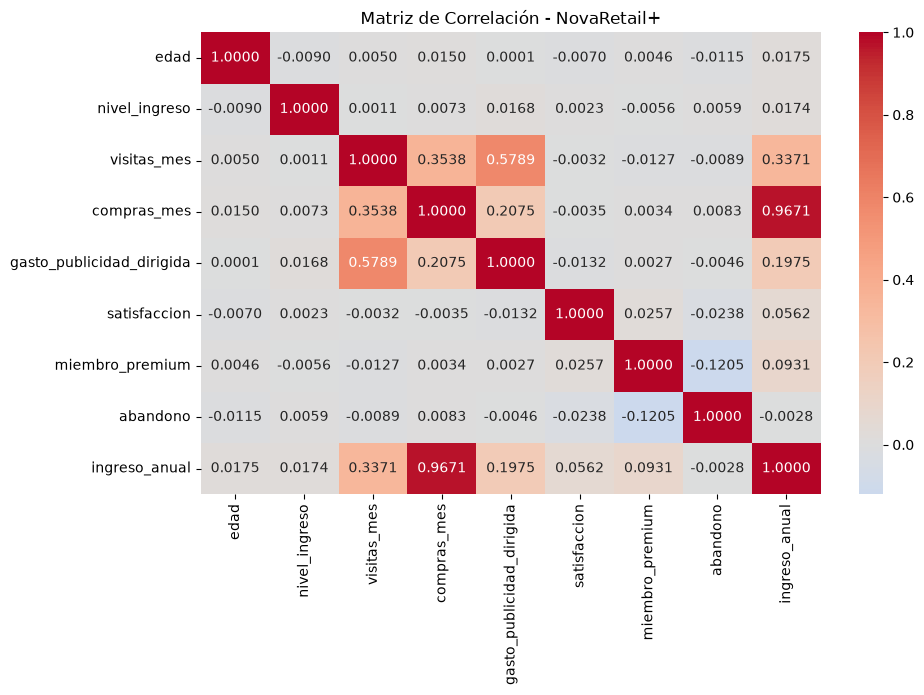

In [9]:
# Visualizar la matriz de correlación para identificar relaciones
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt='.4f')
plt.title("Matriz de Correlación - NovaRetail+")
plt.show()

Observaciones generales (Heatmap)  
- Entre `visitas_mes` y `compras_mes` hay una correlación moderada positiva, a más visitas tiende a haber más compras
- Entre `gasto_publicidad_dirigida` y `visitas_mes` hay una correlación moderada-fuerte positiva, a mayor gasto en publicidad, se generan más visitas
- Entre `gasto_publicidad_dirigida`y `compras_mes` hay una correlación positiva débil, a mayor gasto en publicidad, aumentan ligeramente las compras
- Entre `miembro_premium`y `abandono` hay una correlación débil negativa, los miembros premium suelen abandonar menos la plataforma

Observaciones respecto a `ingreso_anual`  
- Con `compras_mes` es una correlación esperada, ya que a mayor número de compras mayor ingreso anual
- Con `visitas_mes` hay una correlación moderada positiva, más visitas hay una ligera tendencia a más ingreso anual
- Con `gasto_publicidad_dirigida` hay una correlación débil positiva, a mayor gasto en publicidad dirigida, hay una ligera tendencia a más ingresos

### Scatterplot general

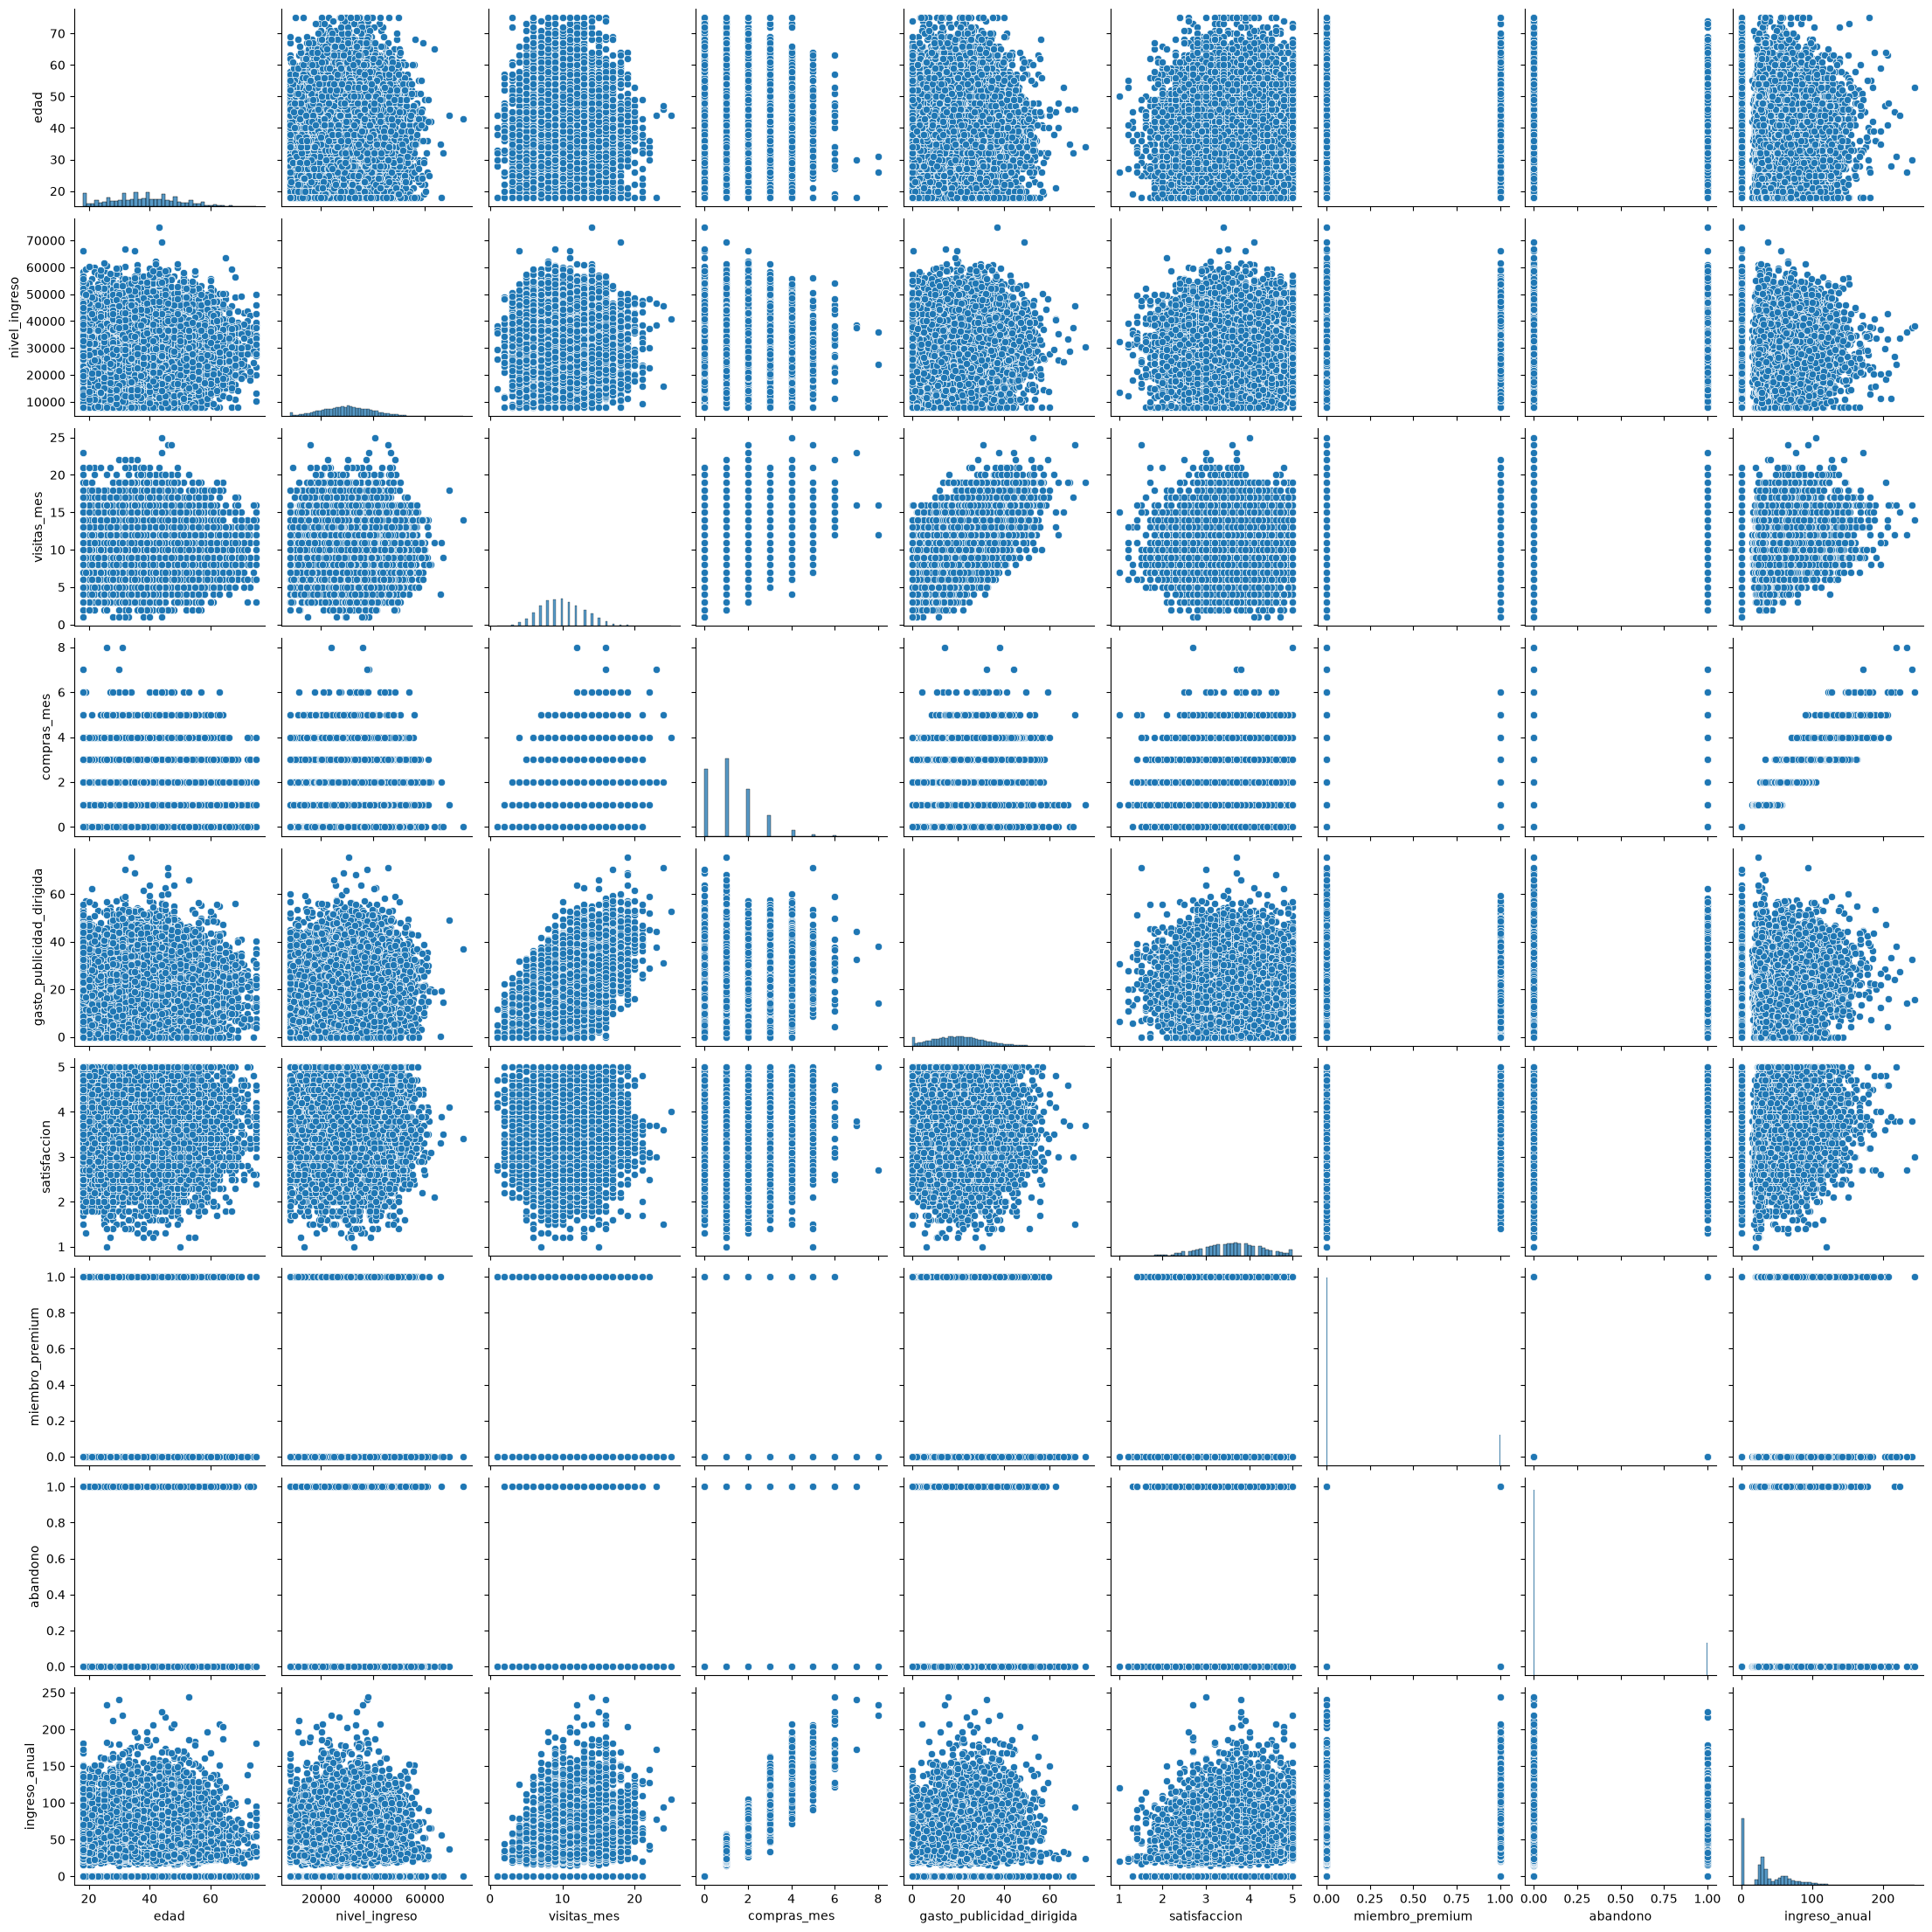

In [10]:
sns.pairplot(df)

- Entre `visitas_mes` vs `compras_mes`, se confirma la correlación moderada positiva, a más visitas tiende a haber más compras
- Entre `gasto_publicidad_dirigida` y `visitas_mes` se confirma la correlación moderada-fuerte positiva, a mayor gasto en publicidad, más visitas se generan
- Entre `gasto_publicidad_dirigida`y `compras_mes` se confirma la correlación moderada-débil positiva, a mayor gasto en publicidad, aumentan ligeramente las compras
- Entre `ingreso_anual` vs `compras_mes` se confirma la tendencia positiva, a más compras mensuales, mayor es el ingreso anual
- Entre `ingreso_anual` vs `visitas_mes` se confirma la correlación moderada-débil, a más visitas hay una ligera tendencia a mayor ingreso anual
- Entre `ingreso_anual` vs `gasto_publicidad_dirigida` hay una correlación pero es muy débil

### Scatterplot para pares clave

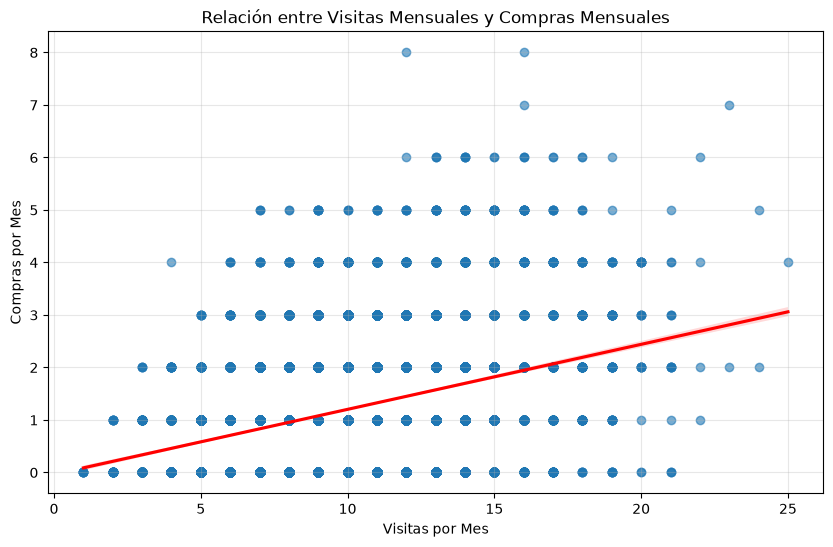

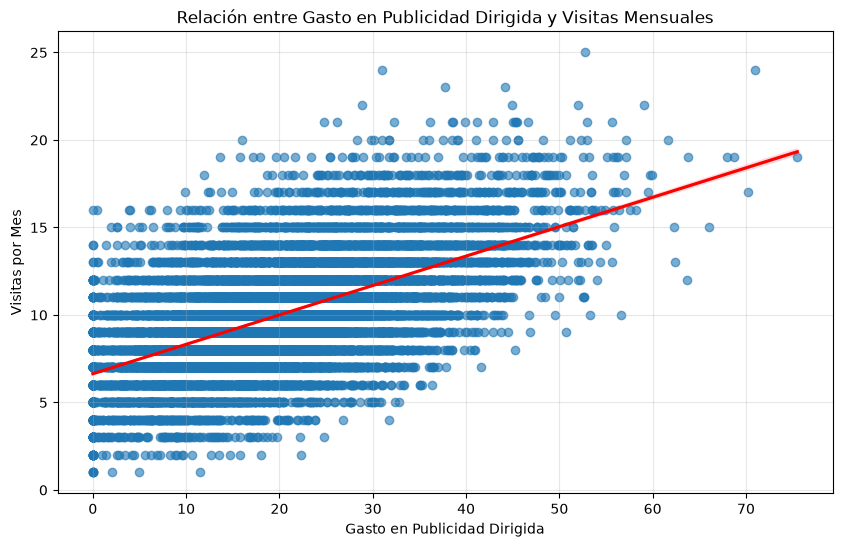

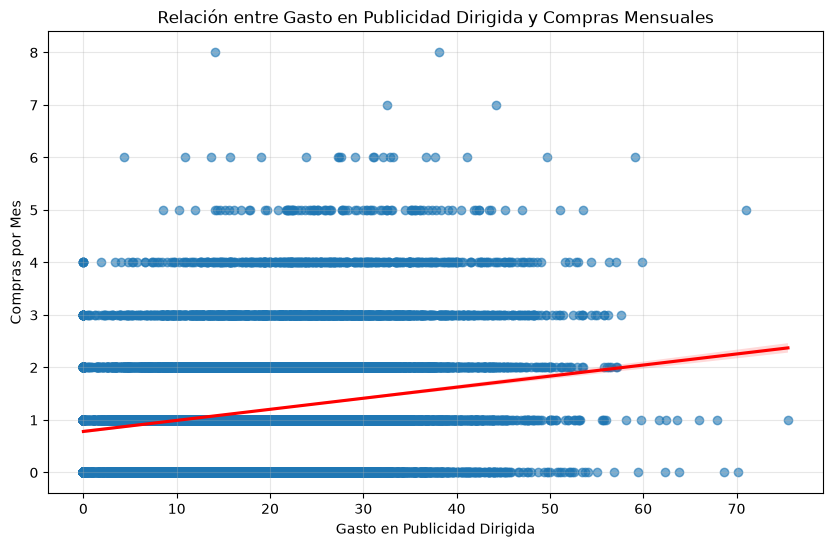

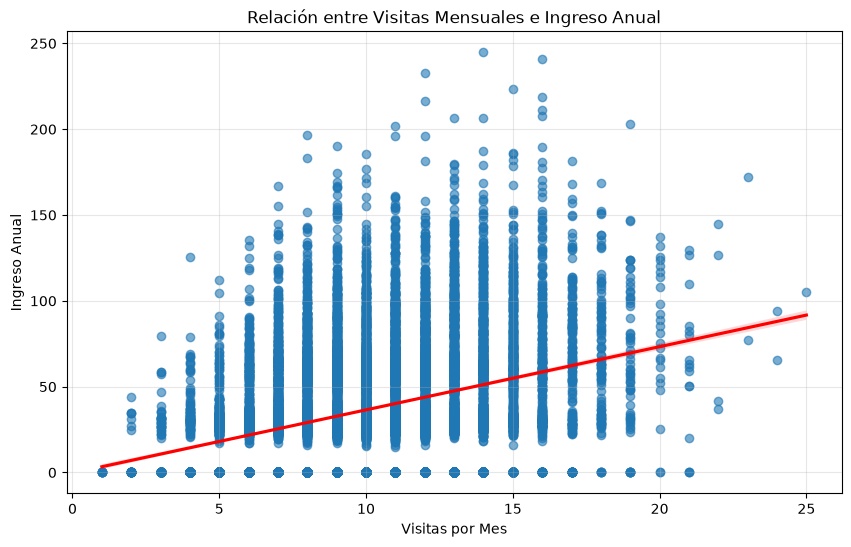

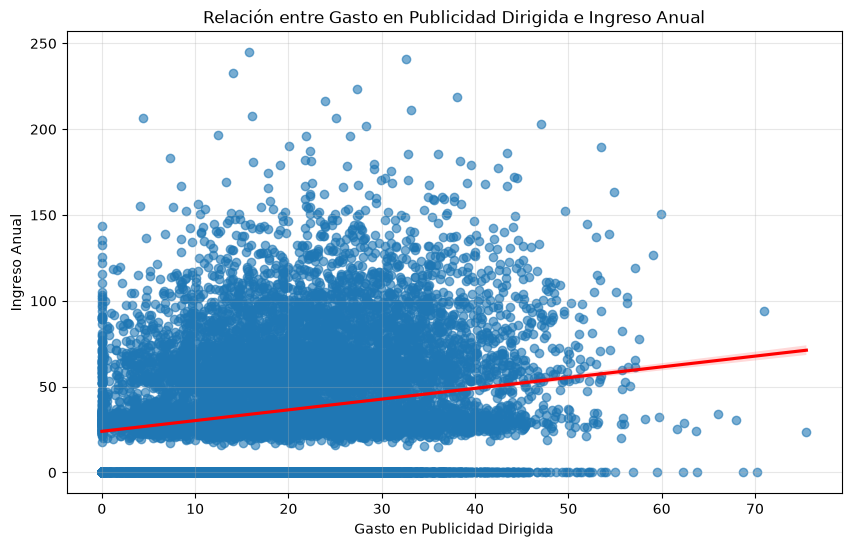

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='visitas_mes', y='compras_mes',
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})
plt.title('Relación entre Visitas Mensuales y Compras Mensuales')
plt.xlabel('Visitas por Mes')
plt.ylabel('Compras por Mes')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes', 
            scatter_kws={'alpha': 0.6}, 
            line_kws={'color': 'red'})
plt.title('Relación entre Gasto en Publicidad Dirigida y Visitas Mensuales')
plt.xlabel('Gasto en Publicidad Dirigida')
plt.ylabel('Visitas por Mes')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='gasto_publicidad_dirigida', y='compras_mes',
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})
plt.title('Relación entre Gasto en Publicidad Dirigida y Compras Mensuales')
plt.xlabel('Gasto en Publicidad Dirigida')
plt.ylabel('Compras por Mes')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='visitas_mes', y='ingreso_anual',
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})
plt.title('Relación entre Visitas Mensuales e Ingreso Anual')
plt.xlabel('Visitas por Mes')
plt.ylabel('Ingreso Anual')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual',
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})
plt.title('Relación entre Gasto en Publicidad Dirigida e Ingreso Anual')
plt.xlabel('Gasto en Publicidad Dirigida')
plt.ylabel('Ingreso Anual')
plt.grid(True, alpha=0.3)
plt.show()

**Visitas Mensuales vs Compras Mensuales**
- Dirección: Positiva
- Dispersión: Media-alta
- Outliers: Presentes
- Colinealidad: No hay, dado que la correlación no es extremadamente alta

**Publicidad Dirigida vs Visitas Mensuales**
- Dirección: Positiva
- Dispersión: Media-alta
- Outliers: Presentes
- Colinealidad: No hay, dado que la correlación no es extremadamente alta

**Publicidad Dirigida vs Compras Mensuales**
- Dirección: Positiva
- Dispersión: Alta
- Outliers: Presentes
- Colinealidad: No hay, dado que la correlación no es extremadamente alta

**Visitas Mensuales vs Ingreso Anual**
- Dirección: Positiva
- Dispersión: Alta
- Outliers: Presentes
- Colinealidad: No hay, dado que la correlación no es extremadamente alta

**Publicidad Dirigida vs Ingreso Anual**
- Dirección: Positiva
- Dispersión: Alta
- Outliers: Presentes
- Colinealidad: No hay, dado que la correlación no es extremadamente alta


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [12]:
# Calcular correlación entre variables relevantes
print("Correlación entre visitas mensuales y compras mensuales")
correlacion_pearson = df['visitas_mes'].corr(df['compras_mes'], method='pearson')
print(f"Correlación de Pearson: {correlacion_pearson:.4f}")
correlacion_spearman = df['visitas_mes'].corr(df['compras_mes'], method='spearman')
print(f"Correlación de Spearman: {correlacion_spearman:.4f}")

print ("\n")

print("Correlación entre publicidad dirigida y visitas mensuales")
correlacion_pearson = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'], method='pearson')
print(f"Correlación de Pearson: {correlacion_pearson:.4f}")
correlacion_spearman = df['visitas_mes'].corr(df['gasto_publicidad_dirigida'], method='spearman')
print(f"Correlación de Spearman: {correlacion_spearman:.4f}")

print ("\n")

print("Correlación entre publicidad dirigida y compras mensuales")
correlacion_pearson = df['compras_mes'].corr(df['gasto_publicidad_dirigida'], method='pearson')
print(f"Correlación de Pearson: {correlacion_pearson:.4f}")
correlacion_spearman = df['compras_mes'].corr(df['gasto_publicidad_dirigida'], method='spearman')
print(f"Correlación de Spearman: {correlacion_spearman:.4f}")

print ("\n")

print("Correlación entre visitas mensuales y ingreso anual")
correlacion_pearson = df['visitas_mes'].corr(df['ingreso_anual'], method='pearson')
print(f"Correlación de Pearson: {correlacion_pearson:.4f}")
correlacion_spearman = df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')
print(f"Correlación de Spearman: {correlacion_spearman:.4f}")

print ("\n")

print("Correlación entre publicidad dirigida y ingreso anual")
correlacion_pearson = df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='pearson')
print(f"Correlación de Pearson: {correlacion_pearson:.4f}")
correlacion_spearman = df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='spearman')
print(f"Correlación de Spearman: {correlacion_spearman:.4f}")

Correlación entre visitas mensuales y compras mensuales
Correlación de Pearson: 0.3538
Correlación de Spearman: 0.3329


Correlación entre publicidad dirigida y visitas mensuales
Correlación de Pearson: 0.5789
Correlación de Spearman: 0.5593


Correlación entre publicidad dirigida y compras mensuales
Correlación de Pearson: 0.2075
Correlación de Spearman: 0.1925


Correlación entre visitas mensuales y ingreso anual
Correlación de Pearson: 0.3371
Correlación de Spearman: 0.3210


Correlación entre publicidad dirigida y ingreso anual
Correlación de Pearson: 0.1975
Correlación de Spearman: 0.1850


**Visitas Mensuales vs Compras Mensuales**
- Dirección: Positiva en ambos coeficientes
- Magnitud: Moderada-débil
- Colinealidad: No hay riesgo

**Publicidad Dirigida vs Visitas Mensuales**
- Dirección: Positiva en ambos coeficientes
- Magnitud: Moderada-fuerte
- Colinealidad: No hay riesgo

**Publicidad Dirigida vs Compras Mensuales**
- Dirección: Positiva en ambos coeficientes
- Magnitud: Débil
- Colinealidad: No hay riesgo

**Visitas Mensuales vs Ingreso Anual**
- Dirección: Positiva en ambos coeficientes
- Magnitud: Moderada-débil
- Colinealidad: No hay riesgo

**Publicidad Dirigida vs Ingreso Anual**
- Dirección: Positiva en ambos coeficientes
- Magnitud: Débil
- Colinealidad: No hay riesgo


### Punto-biserial

In [13]:
# Calcular correlación entre variables relevantes
print("Ingreso Anual vs Miembro Premium")
corr_coef, p_value = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
print(f"Correlación punto biserial: {corr_coef:.4f}")

print("\n")

print("Ingreso Anual vs Abandono")
corr_coef, p_value = pointbiserialr(df['abandono'], df['ingreso_anual'])
print(f"Correlación punto biserial: {corr_coef:.4f}")

print("\n")

print("Miembro Premium vs Compras Mensuales")
corr_coef, p_value = pointbiserialr(df['miembro_premium'], df['compras_mes'])
print(f"Correlación punto biserial: {corr_coef:.4f}")

print("\n")

print("Miembro Premium vs Visitas Mensuales")
corr_coef, p_value = pointbiserialr(df['miembro_premium'], df['visitas_mes'])
print(f"Correlación punto biserial: {corr_coef:.4f}")

print("\n")

print("Abandono vs Compras Mensuales")
corr_coef, p_value = pointbiserialr(df['abandono'], df['compras_mes'])
print(f"Correlación punto biserial: {corr_coef:.4f}")

print("\n")

print("Abandono vs Visitas Mensuales")
corr_coef, p_value = pointbiserialr(df['abandono'], df['visitas_mes'])
print(f"Correlación punto biserial: {corr_coef:.4f}")

print("\n")

print("Miembro Premium vs Abandono")
corr_coef, p_value = pointbiserialr(df['miembro_premium'], df['abandono'])
print(f"Correlación punto biserial: {corr_coef:.4f}")

Ingreso Anual vs Miembro Premium
Correlación punto biserial: 0.0931


Ingreso Anual vs Abandono
Correlación punto biserial: -0.0028


Miembro Premium vs Compras Mensuales
Correlación punto biserial: 0.0034


Miembro Premium vs Visitas Mensuales
Correlación punto biserial: -0.0127


Abandono vs Compras Mensuales
Correlación punto biserial: 0.0083


Abandono vs Visitas Mensuales
Correlación punto biserial: -0.0089


Miembro Premium vs Abandono
Correlación punto biserial: -0.1205


**Ingreso Anual vs Miembro Premium**
- Dirección: Positiva
- Magnitud: No hay

**Ingreso Anual vs Abandono**
- Dirección: Negativa
- Magnitud: No hay

**Miembro Premium vs Compras Mensuales**
- Dirección: Positiva
- Magnitud: No hay

**Miembro Premium vs Visitas Mensuales**
- Dirección: Negativa
- Magnitud: No hay

**Abandono vs Compras Mensuales**
- Dirección: Positiva
- Magnitud: No hay

**Abandono vs Visitas Mensuales**
- Dirección: Negativa
- Magnitud: No hay

**Miembro Premium vs Abandono**
- Dirección: Negativa
- Magnitud: Débil

### V de Cramér

In [14]:
# Función para calcular V de Cramér
print("Tabla de contingencia: Tipo de Dispositivo vs Región")
tabla = pd.crosstab(df["tipo_dispositivo"], df["region"])
print(tabla)

chi2, p, dof, expected = chi2_contingency(tabla)
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))

Tabla de contingencia: Tipo de Dispositivo vs Región
region            este  norte  oeste   sur
tipo_dispositivo                          
escritorio         766   1125    935   894
móvil             2003   2843   2489  2483
tablet             300    427    386   349


In [15]:
# Aplicar V de Cramér en variables relevantes
print(f"V de Cramér: {cramers_v:.4f}")

V de Cramér: 0.0124


Observaciones V de Cramér
- Magnitud: Débil o inexistente = 0.0124
- No hay asociación significativa entre tipo de dispositivo y regiones
- Estrategias de optimización móvil (el más usado) pueden ser uniformes entre regiones

## Sección 5 - Interpretación de resultados para el negocio

**Nota:** Aunque la **correlación más alta observada fue entre `compras_mes` e `ingreso_anual` (0.9671)**, no se profundiza porque **la relación es esperable y aporta menos valor analítico** que otras asociaciones menos evidentes.

### Hallazgo 1 — Las visitas mensuales se asocian de forma moderada-débil con el ingreso anual

**Evidencia visual:**
Scatter plot `visitas_mes` vs `ingreso_anual`: la línea de tendencia muestra una pendiente positiva, aunque con bastante dispersión

**Evidencia numérica:**

Correlación de Pearson: 0.3371

Correlación de Spearman: 0.3210

**Interpretación**  
Los clientes con más visitas tienden a registrar mayor ingreso anual

**No podemos afirmar**  
Que aumentar las visitas de un cliente causará que el ingreso anual suba. Puede ocurrir que los clientes con mayor disposición de compra sean naturalmente los que más visitan la plataforma

**Implicación de negocio**  
Mantener a los clientes activos y visitando la plataforma con frecuencia parece estar asociado con mayores ingresos anuales para el negocio. Vale la pena explorar qué incentiva las visitas recurrentes y si hay segmentos con visitas altas pero ingreso bajo


### Hallazgo 2 — El gasto en publicidad dirigida está moderadamente asociado con más visitas mensuales

**Evidencia visual:**
Scatter plot `gasto_publicidad_dirigida` vs `visitas_mes`: la línea de tendencia (roja) es positiva. A mayor gasto en publicidad, suele darse una mayor concentración de clientes con visitas altas

**Evidencia numérica:** 

Correlación de Pearson: 0.5789

Correlación de Spearman: 0.5593

**Interpretación**  
Los clientes que reciben mayor inversión en publicidad dirigida tienden a visitar más la plataforma durante el mes

**No podemos afirmar**  
Que aumentar el gasto en publicidad causará más visitas. El gasto puede estar asignado de forma diferente a clientes más activos o con cierto perfil, lo que generaría una asociación sin relación causal directa

**Implicación de negocio**  
La publicidad dirigida parece estar asociada con mayor actividad en la plataforma. Conviene evaluar si las visitas adicionales que genera se convierten efectivamente en compras, segmentando por tipo de cliente



### Hallazgo 3 — Ser miembro premium se relaciona con menor abandono

**Evidencia visual:** 
En el heatmap, la celda entre `miembro_premium` y `abandono` aparece en tono azul suave, indicando una relación negativa. El mismo valor aparece en la correlación punto biserial de este par de variables.

**Evidencia numérica:**

Correlación punto biserial: -0.1205

**Interpretación**  
Los clientes con membresía premium tienden a abandonar menos la plataforma. La correlación es débil, pero la dirección es consistente y sugiere que la membresía premium está vinculada con mayor retención

**No podemos afirmar**  
Que la membresía premium sea la causa del menor abandono. También puede ocurrir que quienes ya son más fieles o más activos sean precisamente los que terminan suscribiéndose al plan premium

**Implicación de negocio**  
Vale la pena fortalecer la estrategia de fidelización y revisar qué beneficios del plan premium se asocian con menor abandono. También conviene diseñar acciones para convertir clientes no premium en usuarios más comprometidos

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Algunas relaciones son muy débiles o nulas, no todas las variables ayudan a explicar el comportamiento
- Posibles efectos de segmentación no explorados

### **Próximos pasos** 

Probar segmentación adicional por
- `miembro_premium`
- `region`
- `tipo_dispositivo`

Analizar satisfacción y riesgo de abandono
- Analizar la relación entre `satisfaccion` y `abandono` para identificar clientes con mayor riesgo de irse
- Revisar si la `satisfacción` cambia según la cantidad de visitas, compras o tipo de cliente
  
Revisar conversión de `visitas_mes` a `compras_mes`
- Calcular la tasa de conversión de `visitas_mes` a `compras_mes` por segmento
- Explorar qué factores se relacionan con tasas altas de conversión